# KNN Classifier & Optimal K Selection

The K-Nearest Neighbors (KNN) algorithm classifies instances based on the majority label of their nearest neighbors. Choosing the hyperparameter $K$ (number of neighbors) is critical: too low causes overfitting, while too high causes underfitting. This project fits a KNN diagnostic classifier and runs a parameters search to discover the optimal value of $K$.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Generate synthetic health diagnostic dataset (500 samples)
np.random.seed(99)
n_samples = 500

glucose = np.random.normal(105, 25, n_samples)
bmi = np.random.normal(27, 5, n_samples)
age = np.random.normal(45, 12, n_samples)
blood_pressure = np.random.normal(78, 10, n_samples)

# Classification rule with overlapping boundary noise
p_risk = (
    0.05 
    + 0.35 * (glucose > 125) 
    + 0.25 * (bmi > 32) 
    + 0.20 * (age > 55)
    + 0.10 * (blood_pressure > 90)
).clip(0, 1)

y = np.random.binomial(1, p_risk)

df = pd.DataFrame({
    'Glucose': glucose,
    'BMI': bmi,
    'Age': age,
    'BloodPressure': blood_pressure,
    'Target': y
})

df.head(10)



,Glucose,BMI,Age,BloodPressure,Target
0,101.441029,25.672909,50.149594,89.234197,0
1,156.430543,31.863520,41.931057,71.161349,0
2,112.081549,36.621318,46.890031,96.204795,0
3,138.245299,17.573578,58.278625,65.979697,0
4,101.134454,30.837597,39.461935,74.651722,0
5,103.274229,21.641385,35.320234,58.858635,0
6,123.879512,23.925155,71.262695,52.630928,1
7,125.641166,27.428004,31.318578,78.689439,0
8,102.173270,28.739528,62.363824,93.661925,0
9,45.804060,35.698205,13.913881,62.299031,0


## Data Scaling & Train-Test Partition

Because KNN calculates Euclidean distances between samples, feature scaling is essential. We standard-scale features and split them into 80/20 train/test segments.



In [2]:
X = df.drop(columns=['Target'])
y_target = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42, stratify=y_target)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Optimal K Hyperparameter Selection

We evaluate neighbor values from $K=1$ to $K=25$. For each configuration, we compute the 5-fold cross-validation accuracy on the training partition to locate the optimal $K$ choice.



In [3]:
k_values = range(1, 26)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"Optimal number of neighbors (K): {optimal_k}")
print(f"Max cross-validation accuracy: {max(cv_scores)*100:.2f}%")

# Train final model
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_scaled, y_train)
test_accuracy = final_knn.score(X_test_scaled, y_test)
print(f"Final test partition accuracy: {test_accuracy*100:.2f}%")



Optimal number of neighbors (K): 9
Max cross-validation accuracy: 78.00%
Final test partition accuracy: 80.00%


## Cross-Validation Accuracy Curve

We plot the cross-validation accuracies against values of $K$ using Matplotlib, highlighting the optimal hyperparameter value.



<cell>:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



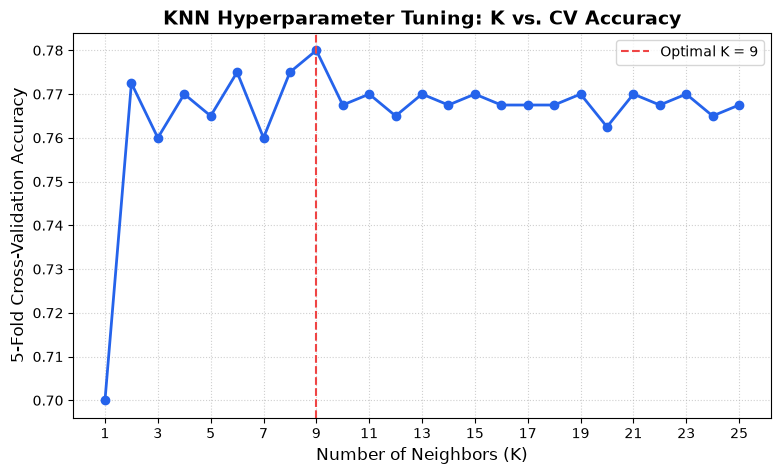

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, cv_scores, marker='o', color='#2563EB', linewidth=2, markersize=6)
plt.axvline(optimal_k, color='#EF4444', linestyle='--', linewidth=1.5, label=f'Optimal K = {optimal_k}')

plt.title('KNN Hyperparameter Tuning: K vs. CV Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('5-Fold Cross-Validation Accuracy', fontsize=12)
plt.xticks(range(1, 26, 2))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
